# 06b — Per Make-Model MAPE Export

**Purpose:** Load the saved XGBoost quantile pkl (no retraining), run inference on the
test split, compute per make-model MAPE, and export to
`models/metadata/make_model_mape.csv` so the ML service uses exact model MAPE
instead of the price-dispersion fallback.

**Pre-requisites:** Notebook 05 must have been run at least once so
`models/pickles/xgb_quantile_models.joblib` and
`models/pickles/label_encoders.joblib` exist.

## 1) Imports & paths

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-dark')

# ── Locate ml-service root ────────────────────────────────────────────────────
def find_ml_root(start=None):
    start = (start or Path.cwd()).resolve()
    for c in (start, *start.parents):
        if (c / 'app' / 'core' / 'config.py').exists():
            return c
    raise FileNotFoundError('Cannot find ml-service root')

ML_ROOT = find_ml_root()
if str(ML_ROOT) not in sys.path:
    sys.path.insert(0, str(ML_ROOT))

from app.core.config import settings

PICKLES_DIR  = ML_ROOT / 'models' / 'pickles'
METADATA_DIR = ML_ROOT / 'models' / 'metadata'
METADATA_DIR.mkdir(parents=True, exist_ok=True)

OUT_CSV = METADATA_DIR / 'make_model_mape.csv'

print('ML_ROOT     :', ML_ROOT)
print('PICKLES_DIR :', PICKLES_DIR)
print('Output CSV  :', OUT_CSV)

ML_ROOT     : /home/mo-seif/Documents/GP/ml-service
PICKLES_DIR : /home/mo-seif/Documents/GP/ml-service/models/pickles
Output CSV  : /home/mo-seif/Documents/GP/ml-service/models/metadata/make_model_mape.csv


## 2) Load saved model & label encoders

In [2]:
MODEL_PKL = PICKLES_DIR / 'xgb_quantile_models.joblib'
LE_PKL    = PICKLES_DIR / 'label_encoders.joblib'

assert MODEL_PKL.exists(), f'Model pkl not found: {MODEL_PKL}'
assert LE_PKL.exists(),    f'Label encoders not found: {LE_PKL}'

models         = joblib.load(MODEL_PKL)   # {'lower': Booster, 'median': Booster, 'upper': Booster}
label_encoders = joblib.load(LE_PKL)

print('Loaded model keys :', list(models.keys()))
print('Label encoder cols:', list(label_encoders.keys()))

Loaded model keys : ['lower', 'median', 'upper']
Label encoder cols: ['make', 'model', 'transmission', 'fuel', 'location', 'body_type', 'drivetrain', 'brand_origin', 'car_segment']


## 3) Load & preprocess data

We reproduce the same preprocessing and split strategy used in notebook 05
(**E – stratified by price range**, `RANDOM_STATE=42`) so the test set is identical.

In [3]:
RANDOM_STATE = 42
TEST_SIZE    = 0.20
MIN_ROWS_PER_MODEL = 5

CAT_COLS = ['make', 'model', 'transmission', 'fuel', 'location',
            'body_type', 'drivetrain', 'brand_origin', 'car_segment']
NUM_COLS = ['year', 'mileage_km', 'mileage_per_year', 'engine_cc',
            'horsepower', 'seating_capacity']
FEATURE_COLS = NUM_COLS + CAT_COLS

df_raw = settings.load_data('processed').copy()
print('Dataset shape:', df_raw.shape)

# ── Rare-category grouping (same threshold as notebook 05) ───────────────────
_model_counts = df_raw.groupby(['make', 'model']).size().reset_index(name='n')
_rare_models  = _model_counts.loc[_model_counts['n'] < MIN_ROWS_PER_MODEL]
RARE_MODEL_SET = set(zip(_rare_models['make'], _rare_models['model']))

def apply_rare_grouping(df):
    df = df.copy()
    if 'model' in df.columns and 'make' in df.columns:
        mask = [(m, mo) in RARE_MODEL_SET
                for m, mo in zip(df['make'], df['model'])]
        df.loc[mask, 'model'] = df.loc[mask, 'make'].apply(lambda x: f'OTHER_{x}')
    return df

df_raw = apply_rare_grouping(df_raw)
print(f'Rare combos collapsed: {len(RARE_MODEL_SET)}')

Dataset shape: (20214, 18)
Rare combos collapsed: 22


In [4]:
from sklearn.model_selection import train_test_split

# ── Reproduce split E: stratified by price bins ───────────────────────────────
def _build_price_bins(price: pd.Series, desired_bins: int = 10) -> pd.Series:
    s = pd.to_numeric(price, errors='coerce').fillna(price.median())
    for q in [desired_bins, 8, 6, 5, 4, 3]:
        try:
            b = pd.qcut(s, q=q, duplicates='drop')
        except Exception:
            continue
        codes = b.cat.codes.astype(int)
        rare  = codes.value_counts()[codes.value_counts() < 2].index
        codes = codes.where(~codes.isin(rare), -1)
        if codes.value_counts().min() >= 2:
            return codes
    return pd.Series(np.zeros(len(s), dtype=int), index=price.index)

strat_price = _build_price_bins(df_raw['price_egp'])
idx_all     = df_raw.index.to_numpy()
tr_idx, te_idx = train_test_split(
    idx_all, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=strat_price
)
print(f'Train: {len(tr_idx):,}   Test: {len(te_idx):,}')

Train: 16,171   Test: 4,043


In [5]:
# ── XGBoost label-encode using the saved encoders ────────────────────────────
df_enc = df_raw[FEATURE_COLS].copy()
for col, le in label_encoders.items():
    if col in df_enc.columns:
        known = set(le.classes_)
        df_enc[col] = df_enc[col].fillna('__MISSING__').astype(str)
        # Map unseen values to __MISSING__ (consistent with notebook 05)
        df_enc[col] = df_enc[col].apply(lambda v: v if v in known else '__MISSING__')
        df_enc[col] = le.transform(df_enc[col])

X_te = df_enc.loc[te_idx]
y_te = df_raw.loc[te_idx, 'price_egp'].values

print('Test feature matrix shape:', X_te.shape)
assert X_te.isnull().sum().sum() == 0, 'Nulls in test features!'

Test feature matrix shape: (4043, 15)


## 4) Inference with saved median model

In [6]:
dm_te  = xgb.DMatrix(X_te, enable_categorical=True)
y_pred = models['median'].predict(dm_te)

# Quick sanity check
eps   = 1e-9
mape  = float(np.mean(np.abs((y_te - y_pred) / np.maximum(np.abs(y_te), eps))) * 100)
r2    = float(r2_score(y_te, y_pred))
mae   = float(mean_absolute_error(y_te, y_pred))
print(f'Overall test metrics — MAPE: {mape:.2f}%  R²: {r2:.4f}  MAE: {mae:,.0f} EGP')

Overall test metrics — MAPE: 13.53%  R²: 0.8925  MAE: 138,277 EGP


## 5) Per make-model MAPE diagnostics

In [7]:
def safe_mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    eps    = 1e-9
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100)

# Build test DataFrame with predictions
df_te = df_raw.loc[te_idx, ['make', 'model', 'price_egp']].copy()
df_te['pred'] = y_pred

model_rows = []
for (brand, mdl), grp in df_te.groupby(['make', 'model']):
    if len(grp) < 5:
        continue
    yt = grp['price_egp'].values
    yp = grp['pred'].values
    model_rows.append(dict(
        make       = brand,
        model      = mdl,
        n          = len(grp),
        MAPE_pct   = safe_mape(yt, yp),
        R2         = float(r2_score(yt, yp)) if len(grp) > 2 else np.nan,
        MAE        = float(mean_absolute_error(yt, yp)),
        mean_price = float(np.mean(yt)),
    ))

df_model_diag = pd.DataFrame(model_rows)
print(f'Make-model combos with ≥5 test rows: {len(df_model_diag)}')
df_model_diag.head(3)

Make-model combos with ≥5 test rows: 218


,make,model,n,MAPE_pct,R2,MAE,mean_price
0,Audi,A3,8,9.370192,0.959064,105906.078125,1.599375e+06
1,Audi,A5,6,6.976022,0.941296,164558.296875,2.488333e+06
2,Audi,Q3,12,8.587678,0.926389,147633.265625,1.936667e+06


In [8]:
print('Top 20 worst MAPE (highest):')
display(
    df_model_diag.nlargest(20, 'MAPE_pct')[['make','model','n','mean_price','MAPE_pct','R2','MAE']].round(1)
)
print('\nTop 20 best MAPE (lowest):')
display(
    df_model_diag.nsmallest(20, 'MAPE_pct')[['make','model','n','mean_price','MAPE_pct','R2','MAE']].round(1)
)

Top 20 worst MAPE (highest):


,make,model,n,mean_price,MAPE_pct,R2,MAE
28,Chevrolet,Avalanche,7,473571.4,130.3,-1.9,233235.3
118,Mercedes,200,9,568888.9,51.9,0.9,224408.5
109,Land Rover,Range Rover Vogue,7,7742857.0,50.9,0.3,2346739.8
168,Porsche,Cayenne,6,5966666.7,49.0,0.9,1087246.5
63,Honda,Accord,7,1047142.9,48.3,0.9,128781.9
169,Porsche,Cayenne S,7,5757142.9,43.3,0.8,1024766.4
54,Ford,Bronco Raptor,10,192000.0,41.7,-6.3,92965.6
130,Mercedes,G63,5,9840000.0,36.5,-1.0,2550350.0
51,Fiat,Shahin,11,108000.0,33.3,-0.0,31155.8
198,SsangYong,Tivoli,5,784000.0,33.1,-0.7,193143.1



Top 20 best MAPE (lowest):


,make,model,n,mean_price,MAPE_pct,R2,MAE
89,Jetour,T2,5,1811000.0,1.2,1.0,21909.4
41,Cupra,Leon,5,1687000.0,2.7,0.7,42931.4
197,Speranza,Tiggo,5,440800.0,2.7,1.0,12101.2
27,Chery,Tiggo 8,6,1077500.0,3.3,0.8,35040.6
108,Land Rover,Range Rover Velar,6,4341666.7,3.4,1.0,144153.4
13,BMW,X6,7,6014285.7,3.7,0.7,223519.0
143,Mitsubishi,Xpander,7,1146428.6,3.7,0.9,42964.0
147,Nissan,Sentra,20,708475.0,3.8,0.9,25322.9
30,Chevrolet,Captiva,8,959375.0,4.1,0.9,36544.6
114,MG,RX5,16,1040625.0,4.4,1.0,45625.9


## 6) MAPE distribution plots

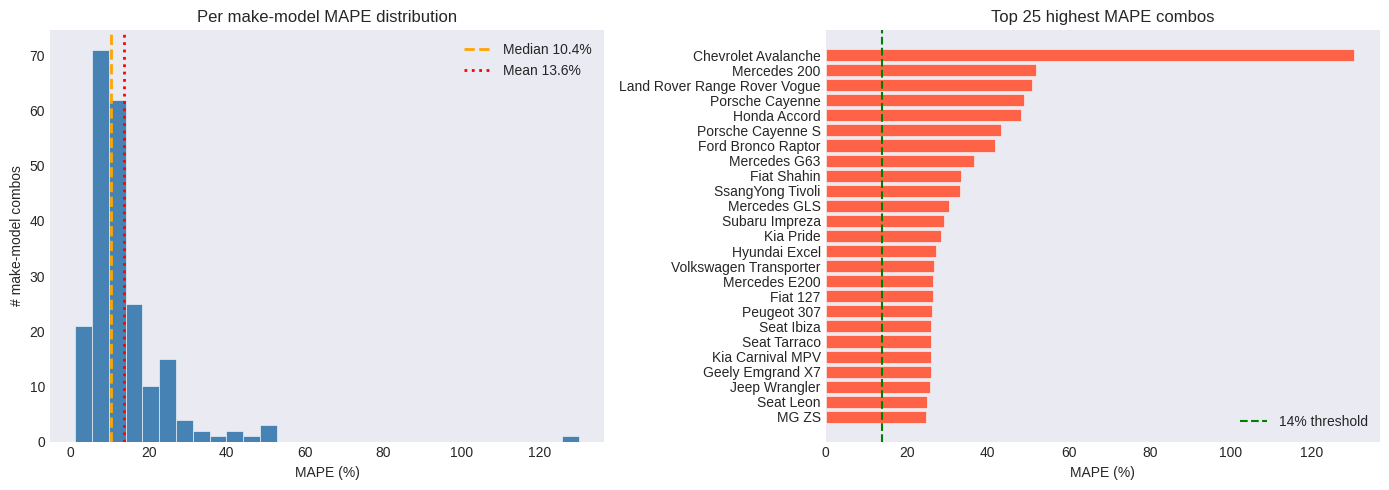

Plot saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of MAPE distribution
axes[0].hist(df_model_diag['MAPE_pct'], bins=30, color='steelblue', edgecolor='white', lw=0.4)
axes[0].axvline(df_model_diag['MAPE_pct'].median(), color='orange', lw=2, linestyle='--',
                label=f'Median {df_model_diag["MAPE_pct"].median():.1f}%')
axes[0].axvline(df_model_diag['MAPE_pct'].mean(), color='red', lw=2, linestyle=':',
                label=f'Mean {df_model_diag["MAPE_pct"].mean():.1f}%')
axes[0].set_xlabel('MAPE (%)')
axes[0].set_ylabel('# make-model combos')
axes[0].set_title('Per make-model MAPE distribution')
axes[0].legend()

# Top 25 worst by MAPE horizontal bar chart
worst25 = df_model_diag.nlargest(25, 'MAPE_pct')
labels  = worst25['make'] + ' ' + worst25['model']
axes[1].barh(labels[::-1], worst25['MAPE_pct'][::-1], color='tomato', edgecolor='white', lw=0.4)
axes[1].axvline(14.0, color='green', lw=1.5, linestyle='--', label='14% threshold')
axes[1].set_xlabel('MAPE (%)')
axes[1].set_title('Top 25 highest MAPE combos')
axes[1].legend()

plt.tight_layout()
plt.savefig(PICKLES_DIR / 'segmented_mape_v2.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

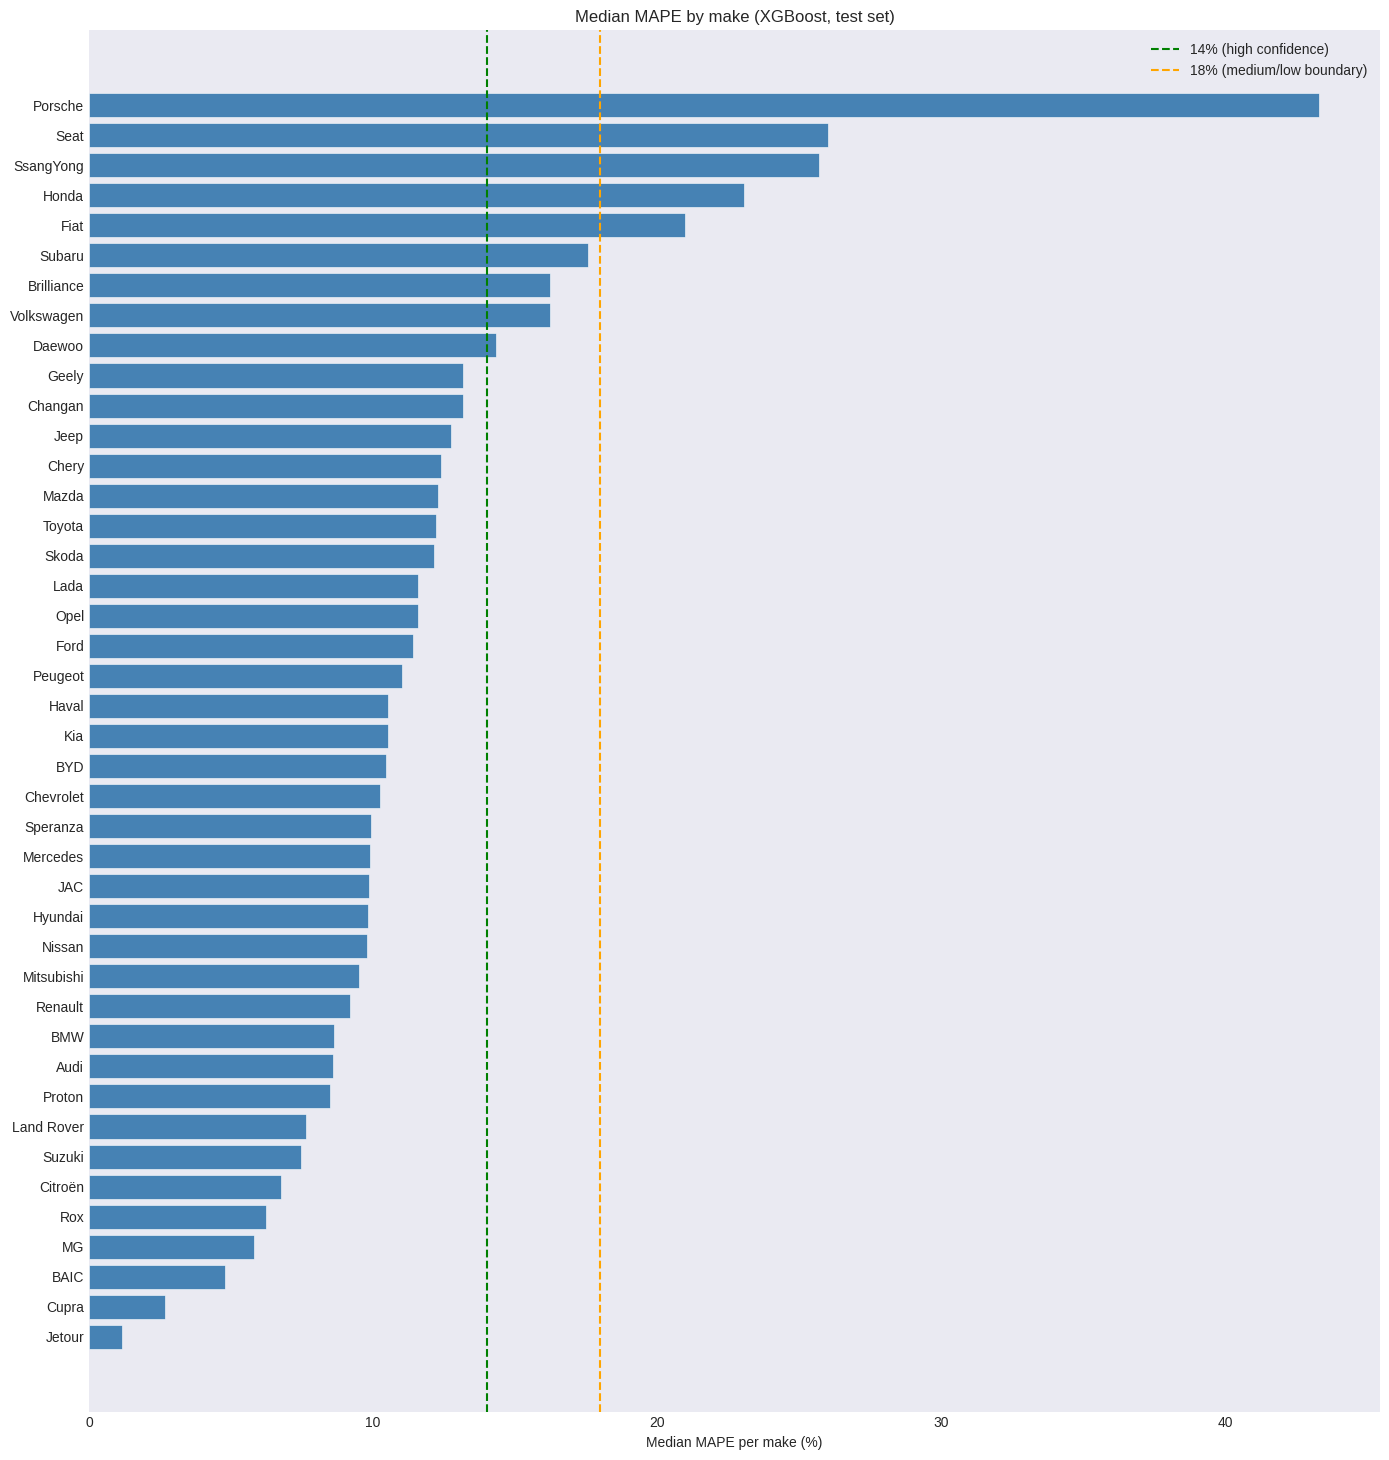

Plot saved.


In [ ]:
# MAPE by make (box / median bar)
make_mape = (
    df_model_diag.groupby('make')['MAPE_pct']
    .agg(['median', 'mean', 'count'])
    .rename(columns={'median': 'MAPE_median', 'mean': 'MAPE_mean', 'count': 'n_models'})
    .sort_values('MAPE_median')
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, max(5, len(make_mape) * 0.35)))
bars = ax.barh(make_mape['make'], make_mape['MAPE_median'], color='steelblue',
               edgecolor='white', lw=0.4)
ax.axvline(14.0, color='green',  lw=1.5, linestyle='--', label='14% (high confidence)')
ax.axvline(18.0, color='orange', lw=1.5, linestyle='--', label='18% (medium/low boundary)')
ax.set_xlabel('Median MAPE per make (%)')
ax.set_title('Median MAPE by make (XGBoost, test set)')
ax.legend()
plt.tight_layout()
plt.savefig(PICKLES_DIR / 'mape_by_make.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

## 7) Export CSV → models/metadata/make_model_mape.csv

This is the file the ML service looks for at startup.
Once it exists the service uses **exact model MAPE per car** instead of the
price-dispersion fallback.

In [11]:
export_cols = ['make', 'model', 'MAPE_pct', 'n', 'MAE', 'R2', 'mean_price']
df_export   = df_model_diag[export_cols].copy()

df_export.to_csv(OUT_CSV, index=False)
print(f'✓ Exported {len(df_export)} rows to {OUT_CSV}')
df_export.head(5)

✓ Exported 218 rows to /home/mo-seif/Documents/GP/ml-service/models/metadata/make_model_mape.csv


,make,model,MAPE_pct,n,MAE,R2,mean_price
0,Audi,A3,9.370192,8,105906.078125,0.959064,1.599375e+06
1,Audi,A5,6.976022,6,164558.296875,0.941296,2.488333e+06
2,Audi,Q3,8.587678,12,147633.265625,0.926389,1.936667e+06
3,BAIC,U5 Plus,4.772879,5,38393.914062,-0.012074,8.390000e+05
4,BMW,218i,8.683106,5,123093.976562,0.810860,1.620000e+06


## 8) Quick verification

Check that the ML service can load the file and the lookup works for a sample car.

In [12]:
# Reload CSV and verify
df_check = pd.read_csv(OUT_CSV)
assert {'make', 'model', 'MAPE_pct'}.issubset(df_check.columns), 'Missing required columns!'
assert len(df_check) == len(df_export), 'Row count mismatch!'

print(f'CSV rows   : {len(df_check)}')
print(f'MAPE range : {df_check["MAPE_pct"].min():.1f}% – {df_check["MAPE_pct"].max():.1f}%')
print(f'MAPE median: {df_check["MAPE_pct"].median():.1f}%')

# Simulate service lookup
def lookup_mape(make, model):
    mk, md = make.strip().lower(), model.strip().lower()
    row = df_check[
        (df_check['make'].str.strip().str.lower() == mk) &
        (df_check['model'].str.strip().str.lower() == md)
    ]
    if len(row):
        return float(row.iloc[0]['MAPE_pct'])
    # Fallback: make-level median
    make_row = df_check[df_check['make'].str.strip().str.lower() == mk]
    if len(make_row):
        return float(make_row['MAPE_pct'].median())
    return None

# Test a few lookups
samples = [('Toyota', 'Corolla'), ('BMW', '3 Series'), ('Hyundai', 'Elantra')]
for make, model in samples:
    mape = lookup_mape(make, model)
    print(f'  {make:12s} {model:15s}  MAPE = {mape}')

CSV rows   : 218
MAPE range : 1.2% – 130.3%
MAPE median: 10.4%
  Toyota       Corolla          MAPE = 9.795539997048522
  BMW          3 Series         MAPE = 8.622093230161141
  Hyundai      Elantra          MAPE = 12.359954783490098


## Done

**Next step:** Restart the ML service. On startup it will log:
```
Loaded per make-model MAPE diagnostics from .../make_model_mape.csv: N combos, M makes
```
instead of the dispersion-fallback warning.  
The `/health` endpoint will also show `"diagnostics_loaded": true`.